#5B Taller aplicado ANN Predicción de la eficiencia de la gasolina

In [ ]:
!pip install ucimlrepo

Realizar un modelo de regresion con redes neuronales densas para predeccir la eficiencia de los vehiculos utilizando un dataset llamado Auto MPG

## Importar librerias

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
import pathlib


from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [3]:
!python -V

Python 3.13.15


In [4]:
print(tf.__version__)

2.20.0


# Importar datos

Este código descarga el dataset Auto MPG, lo carga en Pandas DataFrame y muestra su estructura. Este dataset se usa comúnmente en problemas de regresión para predecir el consumo de combustible de un automóvil en función de características como peso, potencia y cilindros.

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/autompg-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'autompg-dataset' dataset.
Path to dataset files: /kaggle/input/autompg-dataset


In [6]:
from pathlib import Path
df = pd.read_csv(Path(path) / 'auto-mpg.csv')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [7]:
#validar celdas nulas de df
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [8]:
#elimibar la columna car_name
df=df.drop('car name',axis=1)

# EDA

Vamos a graficar la correlaciones utilizador pairplot de seaborn

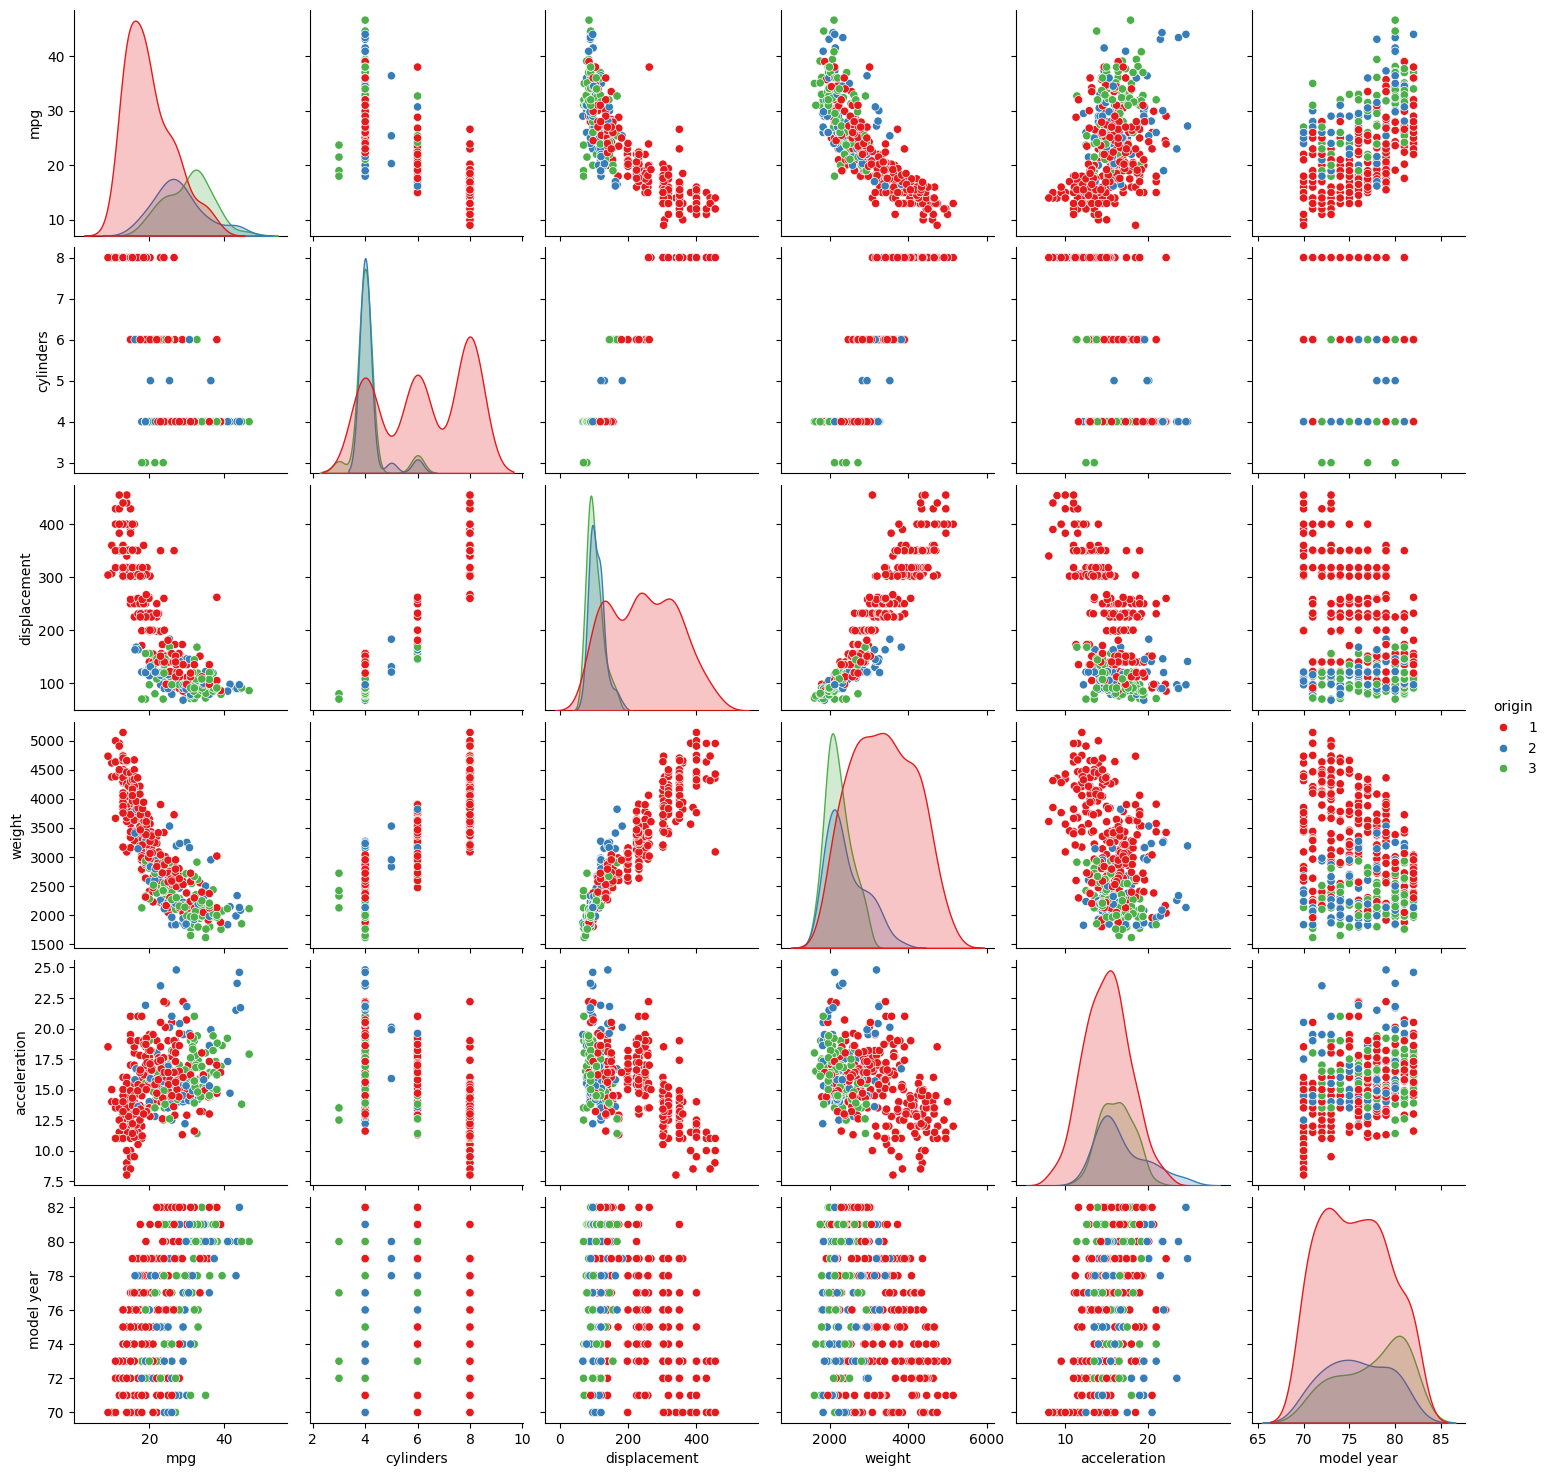

In [9]:
sns.pairplot(df,diag_kind='kde',hue='origin', palette='Set1')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 25.0+ KB


In [11]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1
394,44.0,4,97.0,52,2130,24.6,82,2
395,32.0,4,135.0,84,2295,11.6,82,1
396,28.0,4,120.0,79,2625,18.6,82,1


In [12]:
# convertir horsepower en float, reemplazando '?' con NaN primero
df['horsepower'] = df['horsepower'].replace('?', np.nan)
df['horsepower'] = pd.to_numeric(df['horsepower'])

In [13]:
#imputar en horsepower en el nan la media de horsepower
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mean())

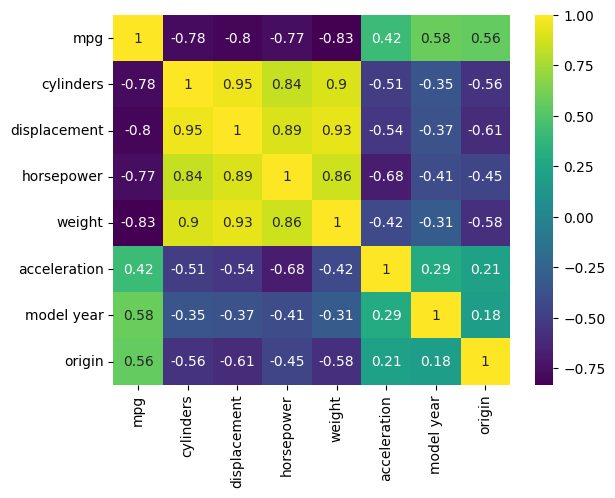

In [14]:
heatmap=sns.heatmap(df.corr(),annot=True,cmap='viridis')

In [15]:
X=df.drop('mpg',axis=1)
y=df['mpg']

In [16]:
#dividr 80% train en X, y colocar la caracteristica mpg
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Procedemos a normalizar dado que estan los features de diferentes escalas.

In [17]:
#normalizar X-train usando standarscaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [18]:
X_train_scaled

array([[ 1.52718818,  1.0901965 ,  1.26183446, ..., -1.31933367,
        -1.6966673 , -0.72949361],
       [-0.85051483, -0.92299623, -0.41351298, ..., -0.41318225,
        -1.6966673 ,  1.73836775],
       [-0.85051483, -0.98134964, -0.95394763, ...,  0.92792185,
         1.63897537,  1.73836775],
       ...,
       [-0.85051483, -0.56315019, -0.22436085, ..., -0.30444408,
         0.52709448,  1.73836775],
       [-0.85051483, -1.00080078, -1.11607803, ...,  0.60170734,
         1.36100515,  1.73836775],
       [-0.85051483, -0.92299623, -1.54842576, ...,  1.94281144,
        -0.86275663,  0.50443707]])

In [19]:

# Crear el modelo secuencial
model = Sequential()

# Añadir la capa de entrada con la forma de entrada
model.add(Input(shape=(X_train.shape[1],)))  # Correcto: 'Input' con 'shape' y no 'Input_shape'

# Añadir las capas densas
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(8, activation='relu'))
model.add(layers.Dense(1,activation='linear'))

In [20]:
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.005),
              loss='mse',
              metrics=['mae'])

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history=model.fit(X_train_scaled,y_train,epochs=500,batch_size=32,validation_split=0.2)

Epoch 1/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - loss: 499.2470 - mae: 21.2188 - val_loss: 353.9447 - val_mae: 17.9294
Epoch 2/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 225.9857 - mae: 13.8429 - val_loss: 114.7942 - val_mae: 9.0157
Epoch 3/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 73.1798 - mae: 7.1348 - val_loss: 57.5863 - val_mae: 6.3121
Epoch 4/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 45.1325 - mae: 5.6032 - val_loss: 41.2008 - val_mae: 5.2166
Epoch 5/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 31.4805 - mae: 4.5379 - val_loss: 26.8576 - val_mae: 4.2641
Epoch 6/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 22.5035 - mae: 3.7893 - val_loss: 22.4482 - val_mae: 3.8210
Epoch 7/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 19.0639 - mae: 3.3836 - val_loss: 16.7042 - val_mae: 3.1345
Epoch 8/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 15.7544 - mae: 3.0563 - val_loss: 13.8767 - val_mae: 2.7944
Epoch 9/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/ste

In [ ]:
# prompt: quiero graficar de la variable historia el history del mae el mse y las perdidas

import matplotlib.pyplot as plt

# Assuming 'history' is the object returned by model.fit
plt.figure(figsize=(10, 6))

# Plot training & validation MAE values
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('Model MAE')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


plt.figure(figsize=(10, 6))

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [ ]:
keras.models.save_model(model,'model_mpg.keras')

In [ ]:
#predecir con los datos de X_test
X_test_scaled = scaler.transform(X_test)
y_pred = model.predict(X_test_scaled)


In [ ]:
#calcular el error medio cuadrático y el erro medio absoluto
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

Realicemos una prediccón

In [ ]:
import pandas as pd
# Cargar el modelo y el escalador
model = keras.models.load_model('model_mpg.keras')
scalador = jb.load('scalador.jb')

# Crear un conjunto de datos de entrada sintético
# Cambiar 'model year' a 'model_year' para que coincida con el nombre de la columna durante el entrenamiento
synthetic_data = pd.DataFrame({
    'cylinders': [4, 6, 8],
    'horsepower': [100, 150, 200],
    'weight': [2500, 3000, 3500],
    'acceleration': [15, 18, 12],
    'model_year': [76, 79, 82],
    'origin': [1, 2, 3]
})

# Escalar los datos sintéticos con el escalador cargado
synthetic_data_scaled = scalador.transform(synthetic_data)

# Hacer la predicción utilizando el modelo cargado
predictions = model.predict(synthetic_data_scaled)

# Mostrar las predicciones
print("Predicciones de MPG para los datos sintéticos:")
for i in range(len(predictions)):
    print(f"Entrada {i + 1}: MPG predicho = {predictions[i][0]}")